# Week 01 - Deep Neural Networks on Fashion-MNIST

**Model file:** `week01_deep_neural_network.py` (ResNet-18 from `torchvision`)
**Benchmark dataset:** Fashion-MNIST (10 clothing classes, 28x28 grayscale)

## What we do here

This notebook has two halves.

1. **Section 3 - one small PyTorch example per lecture section.** Each of the
   five ideas of week 1 gets its own runnable cell, so you can see the equation
   of the lecture notes turn into code and check the numbers yourself.

   | Lecture section | What we build here |
   |---|---|
   | 1. MLP and backpropagation | backward pass written by hand, then checked against `autograd` and against finite differences |
   | 2. Vanishing gradients, activations, initialisation | gradient norm per layer for sigmoid+Xavier vs ReLU+He |
   | 3. Dropout | inverted dropout by hand, the `p` trap of `nn.Dropout`, and a train/validation gap experiment |
   | 4. Batch normalisation | the batch of the lecture example by hand vs `nn.BatchNorm1d`, running statistics, and a learning-rate experiment |
   | 5. Residual learning | a residual block written by hand, and plain vs residual gradient flow at depth 20 |

2. **Sections 4-9 - the real benchmark.** We train the ResNet-18 from the `.py`
   file on Fashion-MNIST with a proper train / validation / test split and
   report accuracy, precision, recall, F1 and a confusion matrix.

| Split | Where it comes from | What we use it for |
|---|---|---|
| train | official training set | update the weights |
| validation | held out from the training set | watch for overfitting, pick the best epoch |
| test | official test set (10,000 images) | the final score we report |

## Runtime

Section 3 takes about one minute on a GPU (a few minutes on CPU). Training in
section 5 takes about 5-10 minutes on a GPU; on CPU lower `N_TRAIN` to about
4000, or lower `EXP_TRAIN` if section 3 feels slow.

## 1. Setup

The notebook must sit in the **same folder** as `week01_deep_neural_network.py`.
We add that folder to `sys.path` and import the file as a normal Python module.

In [1]:
# Standard libraries.
import importlib
import math
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Make the current folder importable, then load the week 1 model file.
HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import week01_deep_neural_network as w1

importlib.reload(w1)  # reload so that edits to the .py file take effect

print("model file loaded:", w1.__file__)
print("class names:", w1.CLASSES)

model file loaded: /home/jovyan/lecture-advanceddeeplearning/week01_deep_neural_network.py
class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [2]:
from torchvision.datasets import FashionMNIST
FashionMNIST.mirrors = [
    "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/"
]

In [3]:
# --- Notebook configuration -------------------------------------------------
SEED = 42
DATA_ROOT = "./data"      # Fashion-MNIST is downloaded here on the first run

N_TRAIN = 20000           # training images (set to None to use all 55,000)
N_VAL = 5000              # validation images held out from the training set
BATCH_SIZE = 128
EPOCHS = 5
LR = 1e-3
STEM = "cifar"            # "cifar" or "imagenet" - see section 3.5
DROPOUT = 0.0             # drop probability before the classifier (PyTorch meaning)
NUM_WORKERS = 0           # keep 0: the transform uses a lambda, which cannot be
                          # sent to worker processes on Windows

# Small-experiment settings used in section 3 (kept tiny so the cells are fast).
EXP_TRAIN = 10000
EXP_EPOCHS = 6

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The helper functions inside the .py file read a module-level DEVICE variable,
# so we point it at the device this notebook uses.
w1.DEVICE = DEVICE

# Fix all random seeds so that two runs give the same numbers.
w1.set_seed(SEED)
np.random.seed(SEED)

print(f"device: {DEVICE}")
if DEVICE.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: NVIDIA RTX 5000 Ada Generation


## 2. Data: the Fashion-MNIST benchmark

Fashion-MNIST has 60,000 training images and 10,000 test images of clothing.
It is a drop-in replacement for MNIST that is harder, so it is a better
benchmark for image classifiers.

ResNet-18 expects **three** colour channels, so we copy the single grayscale
channel three times. We also normalise the pixels with the known Fashion-MNIST
mean and standard deviation.

In [4]:
# Same preprocessing as the .py file: to tensor -> normalise -> repeat channel.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
])

train_full = datasets.FashionMNIST(DATA_ROOT, train=True, download=True,
                                   transform=transform)
test_set = datasets.FashionMNIST(DATA_ROOT, train=False, download=True,
                                 transform=transform)

# Split the official training set into train and validation parts.
generator = torch.Generator().manual_seed(SEED)
permutation = torch.randperm(len(train_full), generator=generator).tolist()

val_indices = permutation[:N_VAL]
train_pool = permutation[N_VAL:]
train_indices = train_pool if N_TRAIN is None else train_pool[:N_TRAIN]

train_set = Subset(train_full, train_indices)
val_set = Subset(train_full, val_indices)

print(f"train: {len(train_set)}   validation: {len(val_set)}   test: {len(test_set)}")

100%|██████████| 26.4M/26.4M [00:00<00:00, 65.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 65.2MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 101MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.41MB/s]


train: 20000   validation: 5000   test: 10000


In [5]:
# Build the three data loaders. Only the training loader is shuffled.
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False,
                        num_workers=NUM_WORKERS)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False,
                         num_workers=NUM_WORKERS)

# Check the class balance of the training split.
train_labels = torch.tensor([train_full.targets[i] for i in train_indices])
counts = torch.bincount(train_labels, minlength=len(w1.CLASSES))
for name, count in zip(w1.CLASSES, counts.tolist()):
    print(f"  {name:<12} {count}")

  T-shirt/top  1953
  Trouser      1966
  Pullover     2008
  Dress        2017
  Coat         2020
  Sandal       2003
  Shirt        1986
  Sneaker      2054
  Bag          1983
  Ankle boot   2010


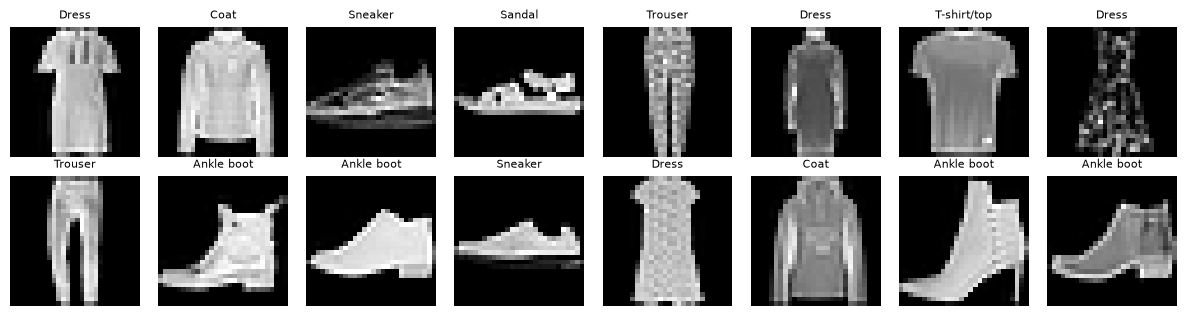

In [6]:
# Look at a few training images so we know what the model sees.
images, labels = next(iter(train_loader))
figure, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, image, label in zip(axes.flat, images, labels):
    # Undo the normalisation and keep one channel for display.
    picture = image[0] * 0.3530 + 0.2860
    ax.imshow(picture.numpy(), cmap="gray")
    ax.set_title(w1.CLASSES[label], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
# A flat, in-memory copy of the data for the small experiments of section 3.
# Working straight from the tensors (no DataLoader) keeps those cells fast.
MEAN, STD = 0.2860, 0.3530

def flat_split(dataset, indices, limit=None):
    idx = torch.tensor(indices[:limit] if limit else indices)
    images = dataset.data[idx].float().div(255.0)
    images = (images - MEAN) / STD
    return images.reshape(len(idx), -1).to(DEVICE), dataset.targets[idx].to(DEVICE)

exp_x, exp_y = flat_split(train_full, train_indices, EXP_TRAIN)
exp_xv, exp_yv = flat_split(train_full, val_indices, 2000)
print("small experiment tensors:", tuple(exp_x.shape), tuple(exp_xv.shape))

small experiment tensors: (10000, 784) (2000, 784)


---

## 3. One PyTorch example per lecture section

Everything below is small on purpose. The point is not accuracy but seeing the
equations of the lecture notes as running code.

### 3.1 Section 1 - backpropagation by hand

The lecture derives three formulas:

* output error &nbsp; $\boldsymbol{\delta}^{(L)} = \hat{\mathbf{y}} - \mathbf{y}$
* error recurrence &nbsp; $\boldsymbol{\delta}^{(\ell)} = \left(W^{(\ell+1)\top}\boldsymbol{\delta}^{(\ell+1)}\right) \odot \sigma'\!\left(\mathbf{z}^{(\ell)}\right)$
* parameter gradient &nbsp; $\partial L / \partial W^{(\ell)} = \boldsymbol{\delta}^{(\ell)}\,\mathbf{a}^{(\ell-1)\top}$ (an outer product)

We write them out for a 3 - 4 - 2 network and compare with `autograd`. We use
`float64` so that the two answers agree to many digits.

In [8]:
torch.manual_seed(0)
d0, d1, d2 = 3, 4, 2

W1 = torch.randn(d1, d0, dtype=torch.float64, requires_grad=True)
b1 = torch.zeros(d1, dtype=torch.float64, requires_grad=True)
W2 = torch.randn(d2, d1, dtype=torch.float64, requires_grad=True)
b2 = torch.zeros(d2, dtype=torch.float64, requires_grad=True)

x = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float64)
y = torch.tensor([0.0, 1.0], dtype=torch.float64)      # one-hot label

# ---- forward pass ----------------------------------------------------------
z1 = W1 @ x + b1
a1 = torch.sigmoid(z1)
z2 = W2 @ a1 + b2
p = torch.softmax(z2, dim=0)
loss = -(y * torch.log(p)).sum()                        # cross entropy

# ---- backward pass, written out by hand ------------------------------------
delta2 = p - y                                          # softmax + CE shortcut
grad_W2 = torch.outer(delta2, a1)                       # outer product
grad_b2 = delta2
delta1 = (W2.T @ delta2) * (a1 * (1 - a1))              # sigmoid'(z) = a(1-a)
grad_W1 = torch.outer(delta1, x)
grad_b1 = delta1

# ---- what autograd says ----------------------------------------------------
loss.backward()

print(f"loss = {loss.item():.6f}")
for name, mine, auto in [("W1", grad_W1, W1.grad), ("b1", grad_b1, b1.grad),
                         ("W2", grad_W2, W2.grad), ("b2", grad_b2, b2.grad)]:
    print(f"  {name}: max |hand - autograd| = {(mine - auto).abs().max().item():.3e}")

loss = 0.876288
  W1: max |hand - autograd| = 1.388e-17
  b1: max |hand - autograd| = 3.469e-18
  W2: max |hand - autograd| = 0.000e+00
  b2: max |hand - autograd| = 0.000e+00


In [9]:
# The outer product explains why a zero input freezes a whole column.
print("a1 (hidden activations):", [round(v, 4) for v in a1.tolist()])
print("delta1 (hidden error)  :", [round(v, 4) for v in delta1.tolist()])
print("\ngrad_W1 = delta1 x^T :")
print(grad_W1)
print("\nInput x =", x.tolist(),
      "-> no component is zero here, so every column of grad_W1 is non-zero.")
print("Set x[1] = 0 and the second column becomes exactly zero:")
print(torch.outer(delta1, torch.tensor([1.0, 0.0, 3.0], dtype=torch.float64)))

a1 (hidden activations): [0.0038, 0.003, 0.4804, 0.2591]
delta1 (hidden error)  : [-0.0006, 0.0013, -0.0261, 0.1829]

grad_W1 = delta1 x^T :
tensor([[-0.0006, -0.0013, -0.0019],
        [ 0.0013,  0.0026,  0.0038],
        [-0.0261, -0.0522, -0.0783],
        [ 0.1829,  0.3657,  0.5486]], dtype=torch.float64,
       grad_fn=<MulBackward0>)

Input x = [1.0, 2.0, 3.0] -> no component is zero here, so every column of grad_W1 is non-zero.
Set x[1] = 0 and the second column becomes exactly zero:
tensor([[-0.0006, -0.0000, -0.0019],
        [ 0.0013,  0.0000,  0.0038],
        [-0.0261, -0.0000, -0.0783],
        [ 0.1829,  0.0000,  0.5486]], dtype=torch.float64,
       grad_fn=<MulBackward0>)


#### Gradient checking

The lecture calls this *the first thing to do when you write backprop yourself*.
We compare the analytic gradient $g$ with the finite difference
$\dfrac{L(\theta+\epsilon) - L(\theta-\epsilon)}{2\epsilon}$
and look at the relative error. Below about $10^{-7}$ (in `float64`) the two
agree.

In [10]:
def loss_fn():
    h = torch.sigmoid(W1 @ x + b1)
    return -(y * torch.log(torch.softmax(W2 @ h + b2, dim=0))).sum()


def gradient_check(parameter, analytic, eps=1e-6, n_checks=6):
    """Compare a few entries of `analytic` with central finite differences."""
    flat = parameter.detach().reshape(-1)
    rows = []
    positions = random.sample(range(flat.numel()), min(n_checks, flat.numel()))
    for pos in positions:
        original = flat[pos].item()
        flat[pos] = original + eps
        plus = loss_fn().item()
        flat[pos] = original - eps
        minus = loss_fn().item()
        flat[pos] = original
        numeric = (plus - minus) / (2 * eps)
        exact = analytic.reshape(-1)[pos].item()
        denominator = max(abs(exact), abs(numeric), 1e-12)
        rows.append((pos, exact, numeric, abs(exact - numeric) / denominator))
    return rows


random.seed(0)
print(f"{'param':<4}{'idx':>5}{'analytic':>14}{'numeric':>14}{'rel.error':>13}")
for name, parameter, analytic in [("W1", W1, grad_W1), ("W2", W2, grad_W2)]:
    for pos, exact, numeric, rel in gradient_check(parameter, analytic):
        print(f"{name:<4}{pos:>5}{exact:>14.8f}{numeric:>14.8f}{rel:>13.2e}")

param  idx      analytic       numeric    rel.error
W1      6   -0.02610734   -0.02610734     2.87e-09
W1     11    0.54855346    0.54855346     2.89e-10
W1      0   -0.00063315   -0.00063315     6.78e-08
W1      4    0.00256477    0.00256477     1.03e-08
W1      7   -0.05221469   -0.05221469     3.23e-10
W1      3    0.00128238    0.00128238     1.03e-08
W2      4   -0.00218881   -0.00218881     4.16e-08
W2      3    0.15124649    0.15124649     3.04e-10
W2      2    0.28040695    0.28040695     1.56e-10
W2      7   -0.15124649   -0.15124649     3.04e-10
W2      1    0.00176811    0.00176811     4.74e-08
W2      5   -0.00176811   -0.00176811     4.74e-08


### 3.2 Section 2 - vanishing gradients, activation functions, initialisation

The lecture states that a sigmoid network loses a factor of at most 0.25 per
layer, so after $L$ layers the error signal is scaled by at most $0.25^{L}$.
Here we build a 20-layer network twice - once with sigmoid + Xavier, once with
ReLU + He - and print the gradient norm of every layer.

derivative peaks:
  max sigmoid'(z) = 0.2500  (lecture: 0.25 at z=0)
  ReLU'(z) = 1 for z > 0, 0 otherwise
  0.25**10 = 9.537e-07   0.25**20 = 9.095e-13


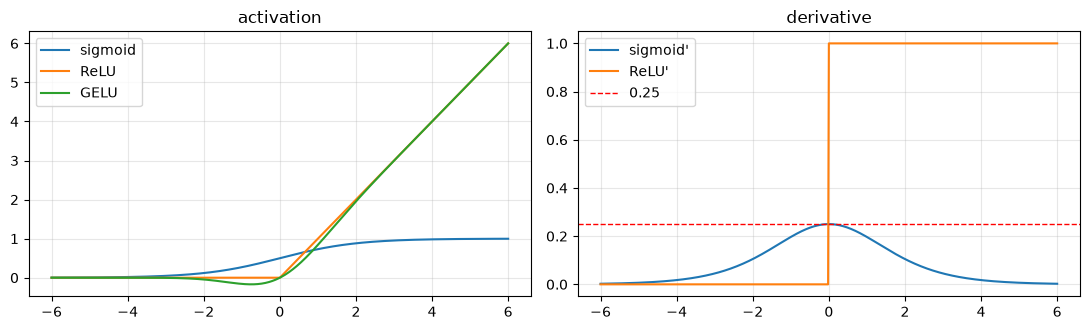

In [11]:
print("derivative peaks:")
z = torch.linspace(-6, 6, 601)
sigmoid_derivative = torch.sigmoid(z) * (1 - torch.sigmoid(z))
print(f"  max sigmoid'(z) = {sigmoid_derivative.max():.4f}  (lecture: 0.25 at z=0)")
print(f"  ReLU'(z) = 1 for z > 0, 0 otherwise")
print(f"  0.25**10 = {0.25 ** 10:.3e}   0.25**20 = {0.25 ** 20:.3e}")

figure, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(z, torch.sigmoid(z), label="sigmoid")
axes[0].plot(z, torch.relu(z), label="ReLU")
axes[0].plot(z, F.gelu(z), label="GELU")
axes[0].set_title("activation")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(z, sigmoid_derivative, label="sigmoid'")
axes[1].plot(z, (z > 0).float(), label="ReLU'")
axes[1].axhline(0.25, color="red", ls="--", lw=1, label="0.25")
axes[1].set_title("derivative")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

 layer    sigmoid + Xavier     ReLU + He
     1           1.755e-13     7.090e-01
     2           1.955e-12     9.459e-01
     3           9.947e-12     1.124e+00
     4           4.070e-11     1.232e+00
     5           1.599e-10     1.488e+00
   ...
    19           9.337e-02     2.083e+00
    20           3.474e-01     2.357e+00
    21           1.039e+00     2.215e+00

first layer / last layer ratio:
  sigmoid + Xavier : 1.690e-13
  ReLU + He        : 3.201e-01


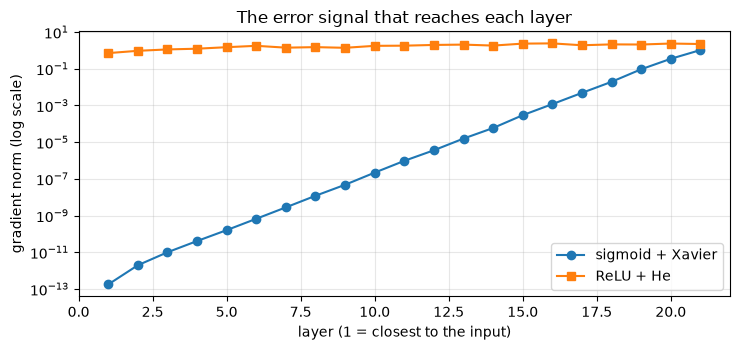

In [12]:
def deep_mlp(depth=20, width=64, activation="sigmoid", init="xavier", seed=0):
    """A plain deep MLP, initialised the way the lecture describes."""
    torch.manual_seed(seed)
    act = {"sigmoid": nn.Sigmoid, "relu": nn.ReLU, "tanh": nn.Tanh}[activation]
    layers = []
    for _ in range(depth):
        layers += [nn.Linear(width, width), act()]
    layers += [nn.Linear(width, 10)]
    model = nn.Sequential(*layers).to(DEVICE)
    for module in model:
        if isinstance(module, nn.Linear):
            if init == "xavier":
                nn.init.xavier_normal_(module.weight)          # Var = 2/(d_in+d_out)
            else:
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")  # Var = 2/d_in
            nn.init.zeros_(module.bias)
    return model


def gradient_norm_per_layer(model, batch=256, width=64):
    torch.manual_seed(1)
    inputs = torch.randn(batch, width, device=DEVICE)
    targets = torch.randint(0, 10, (batch,), device=DEVICE)
    model.zero_grad()
    F.cross_entropy(model(inputs), targets).backward()
    return [m.weight.grad.norm().item() for m in model if isinstance(m, nn.Linear)]


sigmoid_norms = gradient_norm_per_layer(deep_mlp(activation="sigmoid", init="xavier"))
relu_norms = gradient_norm_per_layer(deep_mlp(activation="relu", init="he"))

print(f"{'layer':>6}{'sigmoid + Xavier':>20}{'ReLU + He':>14}")
for i, (s, r) in enumerate(zip(sigmoid_norms, relu_norms), start=1):
    if i <= 5 or i > len(sigmoid_norms) - 3:
        print(f"{i:>6}{s:>20.3e}{r:>14.3e}")
    elif i == 6:
        print(f"{'...':>6}")
print(f"\nfirst layer / last layer ratio:")
print(f"  sigmoid + Xavier : {sigmoid_norms[0] / sigmoid_norms[-1]:.3e}")
print(f"  ReLU + He        : {relu_norms[0] / relu_norms[-1]:.3e}")

plt.figure(figsize=(7.5, 3.6))
plt.semilogy(range(1, len(sigmoid_norms) + 1), sigmoid_norms, marker="o",
             label="sigmoid + Xavier")
plt.semilogy(range(1, len(relu_norms) + 1), relu_norms, marker="s",
             label="ReLU + He")
plt.xlabel("layer (1 = closest to the input)")
plt.ylabel("gradient norm (log scale)")
plt.title("The error signal that reaches each layer")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [13]:
# He initialisation by hand, and the same thing in one line of PyTorch.
d_in = 256
manual_std = math.sqrt(2.0 / d_in)
layer = nn.Linear(d_in, 128)
nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
print(f"He std by hand              : {manual_std:.5f}")
print(f"std of kaiming_normal_      : {layer.weight.std().item():.5f}")
print(f"Xavier std for the same shape: {math.sqrt(2.0 / (d_in + 128)):.5f}")

# Why ReLU needs the factor 2: it zeroes half of a symmetric pre-activation,
# so the second moment is halved.
z = torch.randn(200000)
print(f"\nE[z^2]          = {(z ** 2).mean():.4f}")
print(f"E[ReLU(z)^2]    = {(torch.relu(z) ** 2).mean():.4f}   (about half)")

He std by hand              : 0.08839
std of kaiming_normal_      : 0.08863
Xavier std for the same shape: 0.07217

E[z^2]          = 1.0029
E[ReLU(z)^2]    = 0.5042   (about half)


### 3.3 Section 3 - dropout

Two things to see here.

1. **Inverted dropout** divides by the keep probability *during training*, so
   the expected activation is unchanged and inference needs no rescaling.
2. **The `p` trap.** The dropout paper's $p$ is the probability of *keeping* a
   unit. `nn.Dropout(p)` drops with probability `p`. The paper's input-layer
   setting $p = 0.8$ is therefore `nn.Dropout(p=0.2)` in PyTorch.

In [14]:
torch.manual_seed(0)
activations = torch.rand(20000, 8) + 0.5      # some positive activations
keep_p = 0.5                                  # the PAPER's p (keep probability)

# --- inverted dropout by hand ---
mask = (torch.rand_like(activations) < keep_p).float()
by_hand = mask * activations / keep_p

# --- the same thing with nn.Dropout: drop probability = 1 - keep probability ---
torch_dropout = nn.Dropout(p=1 - keep_p)
torch_dropout.train()
by_torch = torch_dropout(activations)

print(f"paper keep probability p = {keep_p}  ->  nn.Dropout(p={1 - keep_p})")
print(f"  mean of the original activations : {activations.mean():.4f}")
print(f"  mean after hand-written dropout  : {by_hand.mean():.4f}")
print(f"  mean after nn.Dropout            : {by_torch.mean():.4f}")
print(f"  fraction of zeros (hand / torch) : "
      f"{(by_hand == 0).float().mean():.3f} / {(by_torch == 0).float().mean():.3f}")

torch_dropout.eval()
print(f"\nin eval() mode nn.Dropout is the identity: "
      f"{torch.equal(torch_dropout(activations), activations)}")

print("\nThe paper's recommended settings translated to PyTorch:")
print("  hidden layers  paper p = 0.5  ->  nn.Dropout(p=0.5)   (same number by luck)")
print("  input layer    paper p = 0.8  ->  nn.Dropout(p=0.2)   (NOT 0.8)")

paper keep probability p = 0.5  ->  nn.Dropout(p=0.5)
  mean of the original activations : 1.0006
  mean after hand-written dropout  : 1.0008
  mean after nn.Dropout            : 1.0011
  fraction of zeros (hand / torch) : 0.500 / 0.500

in eval() mode nn.Dropout is the identity: True

The paper's recommended settings translated to PyTorch:
  hidden layers  paper p = 0.5  ->  nn.Dropout(p=0.5)   (same number by luck)
  input layer    paper p = 0.8  ->  nn.Dropout(p=0.2)   (NOT 0.8)


In [15]:
def make_mlp(width=512, depth=2, dropout=0.0, batch_norm=False, residual=False,
             in_dim=784, out_dim=10, seed=0):
    """Small MLP used by the experiments in 3.3, 3.4 and 3.5."""
    torch.manual_seed(seed)
    if residual:
        return ResidualMLP(width, depth, in_dim, out_dim).to(DEVICE)
    layers, previous = [], in_dim
    for _ in range(depth):
        # With BatchNorm the bias of the previous layer is redundant: BN
        # subtracts the batch mean, and its own beta plays the role of a bias.
        layers.append(nn.Linear(previous, width, bias=not batch_norm))
        if batch_norm:
            layers.append(nn.BatchNorm1d(width))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(p=dropout))
        previous = width
    layers.append(nn.Linear(previous, out_dim))
    return nn.Sequential(*layers).to(DEVICE)


def train_mlp(model, x, y, xv, yv, epochs=EXP_EPOCHS, lr=1e-3, batch=128, seed=0):
    """Train on tensors that already live on the device. Returns a history dict."""
    torch.manual_seed(seed)
    optimiser = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = {"train_acc": [], "val_acc": [], "train_loss": []}
    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(x), device=x.device)
        total = 0.0
        for start in range(0, len(x), batch):
            index = order[start:start + batch]
            loss = F.cross_entropy(model(x[index]), y[index])
            optimiser.zero_grad(); loss.backward(); optimiser.step()
            total += loss.item() * len(index)
        model.eval()
        with torch.no_grad():
            history["train_loss"].append(total / len(x))
            history["train_acc"].append((model(x).argmax(1) == y).float().mean().item())
            history["val_acc"].append((model(xv).argmax(1) == yv).float().mean().item())
    return history


results = {}
for drop in [0.0, 0.5]:
    model = make_mlp(width=1024, depth=2, dropout=drop)
    results[drop] = train_mlp(model, exp_x, exp_y, exp_xv, exp_yv, lr=0.05)

print(f"{'nn.Dropout(p)':>14}{'train acc':>12}{'val acc':>10}{'gap':>9}")
for drop, history in results.items():
    train_accuracy = history["train_acc"][-1]
    val_accuracy = history["val_acc"][-1]
    print(f"{drop:>14.1f}{train_accuracy:>12.4f}{val_accuracy:>10.4f}"
          f"{train_accuracy - val_accuracy:>9.4f}")
print("\nA smaller gap means less memorising of the training split.")

 nn.Dropout(p)   train acc   val acc      gap
           0.0      0.9088    0.8485   0.0603
           0.5      0.8476    0.8185   0.0291

A smaller gap means less memorising of the training split.


### 3.4 Section 4 - batch normalisation

First the four lines of the batch normalising transform on the exact batch used
in the lecture, $x = (2, 4, 4, 6)$, then the same batch through
`nn.BatchNorm1d`. Watch two details: PyTorch normalises with the **biased**
variance but stores the **unbiased** one in `running_var`, and `eval()` mode
switches from batch statistics to those running statistics.

In [16]:
x_batch = torch.tensor([[2.0], [4.0], [4.0], [6.0]])
gamma, beta, eps = 3.0, 1.0, 1e-5

mu = x_batch.mean()
var = ((x_batch - mu) ** 2).mean()                      # biased, as in the paper
x_hat = (x_batch - mu) / torch.sqrt(var + eps)
y_hand = gamma * x_hat + beta

print(f"mu = {mu:.4f}   var = {var:.4f}   sqrt(var) = {math.sqrt(var):.4f}")
print("x_hat  :", [round(v, 4) for v in x_hat.flatten().tolist()])
print("y (hand):", [round(v, 4) for v in y_hand.flatten().tolist()])

bn = nn.BatchNorm1d(1, eps=eps, momentum=0.1)
with torch.no_grad():
    bn.weight.fill_(gamma); bn.bias.fill_(beta)
bn.train()
y_torch = bn(x_batch)
print("y (torch):", [round(v, 4) for v in y_torch.flatten().tolist()])
print(f"max difference: {(y_hand - y_torch).abs().max().item():.2e}")

m = x_batch.numel()
print(f"\nrunning_mean = {bn.running_mean.item():.4f}   "
      f"running_var = {bn.running_var.item():.4f}")
print(f"unbiased variance m/(m-1) * var = {m / (m - 1) * var:.4f}  "
      "-> this is what PyTorch stores")
print("running statistics start at mean 0 / var 1 and move by `momentum` each")
print("batch, so after a single batch they are still mostly the initial values.")

bn.eval()
print("\nsame batch in eval() mode (running statistics, not batch statistics):",
      [round(v, 4) for v in bn(x_batch).flatten().tolist()])
print("After a full epoch of batches those running statistics settle down and")
print("eval() output becomes close to the training-time output.")

mu = 4.0000   var = 2.0000   sqrt(var) = 1.4142
x_hat  : [-1.4142, 0.0, 0.0, 1.4142]
y (hand): [-3.2426, 1.0, 1.0, 5.2426]
y (torch): [-3.2426, 1.0, 1.0, 5.2426]
max difference: 0.00e+00

running_mean = 0.4000   running_var = 1.1667
unbiased variance m/(m-1) * var = 2.6667  -> this is what PyTorch stores
running statistics start at mean 0 / var 1 and move by `momentum` each
batch, so after a single batch they are still mostly the initial values.

same batch in eval() mode (running statistics, not batch statistics): [5.4439, 10.9988, 10.9988, 16.5537]
After a full epoch of batches those running statistics settle down and
eval() output becomes close to the training-time output.


             model      lr   val acc
             no BN    0.05    0.8445
             no BN     0.5    0.1010
           with BN    0.05    0.8470
           with BN     0.5    0.8375


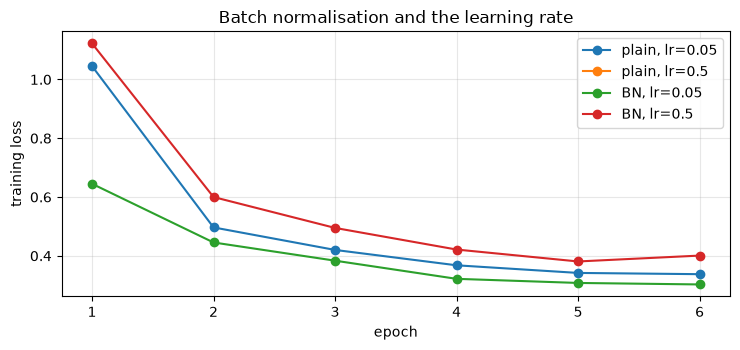

In [17]:
# BatchNorm lets us raise the learning rate - the main claim of section 4.4.
print(f"{'model':>18}{'lr':>8}{'val acc':>10}")
bn_curves = {}
for batch_norm in [False, True]:
    for lr in [0.05, 0.5]:
        model = make_mlp(width=512, depth=3, batch_norm=batch_norm)
        history = train_mlp(model, exp_x, exp_y, exp_xv, exp_yv, lr=lr)
        bn_curves[(batch_norm, lr)] = history
        label = "with BN" if batch_norm else "no BN"
        print(f"{label:>18}{lr:>8}{history['val_acc'][-1]:>10.4f}")

plt.figure(figsize=(7.5, 3.6))
for (batch_norm, lr), history in bn_curves.items():
    label = f"{'BN' if batch_norm else 'plain'}, lr={lr}"
    plt.plot(range(1, EXP_EPOCHS + 1), history["train_loss"], marker="o", label=label)
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Batch normalisation and the learning rate")
plt.tight_layout(); plt.show()

### 3.5 Section 5 - residual learning

The residual block of the lecture, written out:

```
identity <- x
out <- ReLU(BatchNorm(conv3x3(x)))
out <- BatchNorm(conv3x3(out))
out <- out + identity
out <- ReLU(out)
```

We build it, check that it matches `torchvision`'s own `BasicBlock` in shape and
parameter count, and then measure the gradient that reaches layer 1 of a
20-layer network with and without the shortcut.

In [18]:
class BasicResidualBlock(nn.Module):
    """The two-layer residual block of the lecture (same input/output shape)."""

    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x                                   # the shortcut
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity                           # F(x) + x
        return F.relu(out)


from torchvision.models.resnet import BasicBlock

mine = BasicResidualBlock(64)
theirs = BasicBlock(64, 64)
sample = torch.zeros(2, 64, 8, 8)
print("our block :", tuple(mine(sample).shape),
      f"{sum(p.numel() for p in mine.parameters()):,} parameters")
print("torchvision:", tuple(theirs(sample).shape),
      f"{sum(p.numel() for p in theirs.parameters()):,} parameters")

# The bottleneck arithmetic of the lecture.
plain = 256 * 256 * 9 * 2
bottleneck = 256 * 64 + 64 * 64 * 9 + 64 * 256
print(f"\ntwo 3x3 convolutions at 256 channels : {plain:,} weights")
print(f"1x1 -> 3x3 -> 1x1 bottleneck          : {bottleneck:,} weights "
      f"({plain / bottleneck:.1f}x fewer)")

our block : (2, 64, 8, 8) 73,984 parameters
torchvision: (2, 64, 8, 8) 73,984 parameters

two 3x3 convolutions at 256 channels : 1,179,648 weights
1x1 -> 3x3 -> 1x1 bottleneck          : 69,632 weights (16.9x fewer)


In [19]:
class ResidualMLP(nn.Module):
    """Depth-`depth` MLP where every block adds its input back: x + F(x)."""

    def __init__(self, width, depth, in_dim=784, out_dim=10):
        super().__init__()
        self.stem = nn.Linear(in_dim, width)
        self.blocks = nn.ModuleList(
            nn.Sequential(nn.Linear(width, width), nn.ReLU(), nn.Linear(width, width))
            for _ in range(depth))
        self.head = nn.Linear(width, out_dim)

    def forward(self, x):
        h = F.relu(self.stem(x))
        for block in self.blocks:
            h = F.relu(h + block(h))                   # F(h) + h
        return self.head(h)


def first_layer_gradient(depth=20, width=64, residual=False, seed=0):
    torch.manual_seed(seed)
    if residual:
        model = ResidualMLP(width, depth, in_dim=width).to(DEVICE)
        first = model.stem
    else:
        layers = []
        for _ in range(depth):
            layers += [nn.Linear(width, width), nn.ReLU()]
        layers += [nn.Linear(width, 10)]
        model = nn.Sequential(*layers).to(DEVICE)
        first = model[0]
    inputs = torch.randn(256, width, device=DEVICE)
    targets = torch.randint(0, 10, (256,), device=DEVICE)
    model.zero_grad()
    F.cross_entropy(model(inputs), targets).backward()
    return first.weight.grad.norm().item()


print(f"{'depth':>7}{'plain':>14}{'residual':>14}{'ratio':>10}")
for depth in [2, 5, 10, 20, 40]:
    plain_norm = first_layer_gradient(depth=depth, residual=False)
    residual_norm = first_layer_gradient(depth=depth, residual=True)
    ratio = residual_norm / max(plain_norm, 1e-30)
    print(f"{depth:>7}{plain_norm:>14.3e}{residual_norm:>14.3e}{ratio:>10.1f}")
print("\nThe identity path keeps a direct route from the loss to layer 1,")
print("so the product of Jacobians becomes a sum with an I term in it.")

  depth         plain      residual     ratio
      2     8.417e-02     1.954e-01       2.3
      5     5.898e-03     2.027e-01      34.4
     10     7.280e-05     2.087e-01    2866.4
     20     8.921e-09     2.549e-0128576240.2
     40     4.381e-16     2.922e-01666796619906417.0

The identity path keeps a direct route from the loss to layer 1,
so the product of Jacobians becomes a sum with an I term in it.


In [20]:
# Degradation: a deeper plain network can have a WORSE training loss.
print(f"{'depth':>7}{'plain train loss':>20}{'residual train loss':>22}")
for depth in [2, 8, 16]:
    plain_model = make_mlp(width=256, depth=depth * 2)      # two layers per block
    residual_model = make_mlp(width=256, depth=depth, residual=True)
    plain_history = train_mlp(plain_model, exp_x, exp_y, exp_xv, exp_yv, lr=0.05)
    residual_history = train_mlp(residual_model, exp_x, exp_y, exp_xv, exp_yv, lr=0.05)
    print(f"{depth * 2:>7}{plain_history['train_loss'][-1]:>20.4f}"
          f"{residual_history['train_loss'][-1]:>22.4f}")
print("\nWatch the plain column as the depth grows: this is the degradation")
print("problem, and it is a TRAINING loss, so it is not overfitting.")

  depth    plain train loss   residual train loss
      4              0.3679                0.3287
     16              2.3035                0.3205
     32              2.3035                0.3550

Watch the plain column as the depth grows: this is the degradation
problem, and it is a TRAINING loss, so it is not overfitting.


In [21]:
# Why the .py file uses a CIFAR-style stem for 28x28 images.
for stem in ["imagenet", "cifar"]:
    model = w1.build_model(stem=stem)
    shapes = w1.stage_shapes(model, size=28)
    line = "  ".join(f"{k}:{v[1]}x{v[2]}" for k, v in shapes.items())
    print(f"{stem:>9}   {line}")
print("\nWith the ImageNet stem the map is 1x1 by layer4, so the deepest")
print("residual stage has no spatial information left to work with.")

 imagenet   stem:7x7  layer1:7x7  layer2:4x4  layer3:2x2  layer4:1x1
    cifar   stem:28x28  layer1:28x28  layer2:14x14  layer3:7x7  layer4:4x4

With the ImageNet stem the map is 1x1 by layer4, so the deepest
residual stage has no spatial information left to work with.


---

## 4. Model

`w1.build_model()` returns a `torchvision` ResNet-18 with a 10-class output
layer. `stem="cifar"` swaps the 7x7 stride-2 stem for a 3x3 stride-1 one, which
is the right choice for 28x28 inputs (see 3.5). `pretrained=True` loads the
ImageNet weights instead of training from scratch.

In [22]:
model = w1.build_model(stem=STEM, dropout=DROPOUT)
print(f"ResNet-18 ({STEM} stem) parameters: {w1.count_parameters(model) / 1e6:.2f} M")
print("feature map per stage:", w1.stage_shapes(model, size=28))
print(model.fc)  # the final classification layer

ResNet-18 (cifar stem) parameters: 11.17 M
feature map per stage: {'stem': (64, 28, 28), 'layer1': (64, 28, 28), 'layer2': (128, 14, 14), 'layer3': (256, 7, 7), 'layer4': (512, 4, 4)}
Linear(in_features=512, out_features=10, bias=True)


## 5. Training

We reuse `w1.train_one_epoch` and `w1.evaluate` from the `.py` file and add a
loop that records the numbers of every epoch. We keep a copy of the weights
from the epoch with the best **validation** accuracy - this is called early
model selection, and it is why we need a validation split.

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

history = {"train_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
best_state = None

start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss = w1.train_one_epoch(model, train_loader, criterion, optimizer)
    train_acc = w1.evaluate(model, train_loader)
    val_acc = w1.evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Keep the best weights seen so far, judged on the validation split.
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        marker = "  <- best so far"
    else:
        marker = ""

    print(f"epoch {epoch}/{EPOCHS}  train_loss={train_loss:.4f}  "
          f"train_acc={train_acc:.4f}  val_acc={val_acc:.4f}{marker}")

print(f"\ntraining time: {time.time() - start_time:.1f} s")

# Load the best weights back before we test.
model.load_state_dict(best_state)
print(f"best validation accuracy: {best_val_acc:.4f}")

epoch 1/5  train_loss=0.4885  train_acc=0.8608  val_acc=0.8438  <- best so far
epoch 2/5  train_loss=0.2955  train_acc=0.9069  val_acc=0.8746  <- best so far
epoch 3/5  train_loss=0.2424  train_acc=0.9267  val_acc=0.8878  <- best so far
epoch 4/5  train_loss=0.1865  train_acc=0.9482  val_acc=0.9008  <- best so far
epoch 5/5  train_loss=0.1560  train_acc=0.9385  val_acc=0.8838

training time: 55.9 s
best validation accuracy: 0.9008


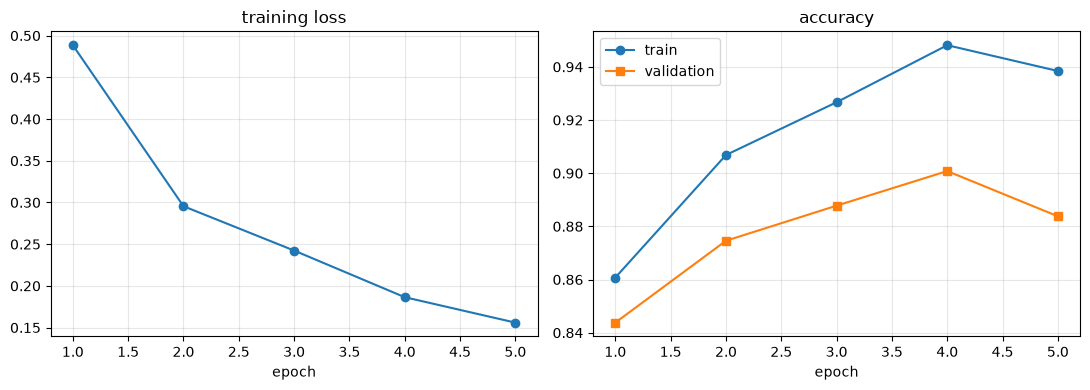

In [24]:
# Learning curves. If the train accuracy keeps rising while the validation
# accuracy stops, the model has started to memorise the training data.
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, EPOCHS + 1), history["train_loss"], marker="o")
axes[0].set_title("training loss")
axes[0].set_xlabel("epoch")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), history["train_acc"], marker="o", label="train")
axes[1].plot(range(1, EPOCHS + 1), history["val_acc"], marker="s", label="validation")
axes[1].set_title("accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Inference on the test set

We now run the model once over the whole test set and keep every prediction,
so we can compute detailed metrics afterwards.

In [25]:
@torch.no_grad()
def collect_predictions(model, loader):
    """Return (true labels, predicted labels, class probabilities)."""
    model.eval()
    all_true, all_pred, all_prob = [], [], []
    for images, targets in loader:
        images = images.to(DEVICE)
        logits = model(images)
        probabilities = logits.softmax(dim=1).cpu()
        all_true.append(targets)
        all_pred.append(probabilities.argmax(dim=1))
        all_prob.append(probabilities)
    return torch.cat(all_true), torch.cat(all_pred), torch.cat(all_prob)


y_true, y_pred, y_prob = collect_predictions(model, test_loader)
test_accuracy = (y_true == y_pred).float().mean().item()
print(f"test accuracy: {test_accuracy:.4f}  ({len(y_true)} images)")

test accuracy: 0.8984  (10000 images)


## 7. Performance evaluation

Accuracy alone hides a lot. We also look at:

* **precision** - of all images the model called class *c*, how many were really *c*?
* **recall** - of all real class *c* images, how many did the model find?
* **F1** - the harmonic mean of precision and recall.
* **confusion matrix** - which classes get mixed up with which.

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true.numpy(), y_pred.numpy(),
                            target_names=w1.CLASSES, digits=4))

              precision    recall  f1-score   support

 T-shirt/top     0.9159    0.7510    0.8253      1000
     Trouser     0.9908    0.9740    0.9823      1000
    Pullover     0.8721    0.8590    0.8655      1000
       Dress     0.8232    0.9500    0.8821      1000
        Coat     0.8316    0.8740    0.8523      1000
      Sandal     0.9846    0.9610    0.9727      1000
       Shirt     0.7116    0.7130    0.7123      1000
     Sneaker     0.9263    0.9800    0.9524      1000
         Bag     0.9711    0.9740    0.9725      1000
  Ankle boot     0.9793    0.9480    0.9634      1000

    accuracy                         0.8984     10000
   macro avg     0.9007    0.8984    0.8981     10000
weighted avg     0.9007    0.8984    0.8981     10000



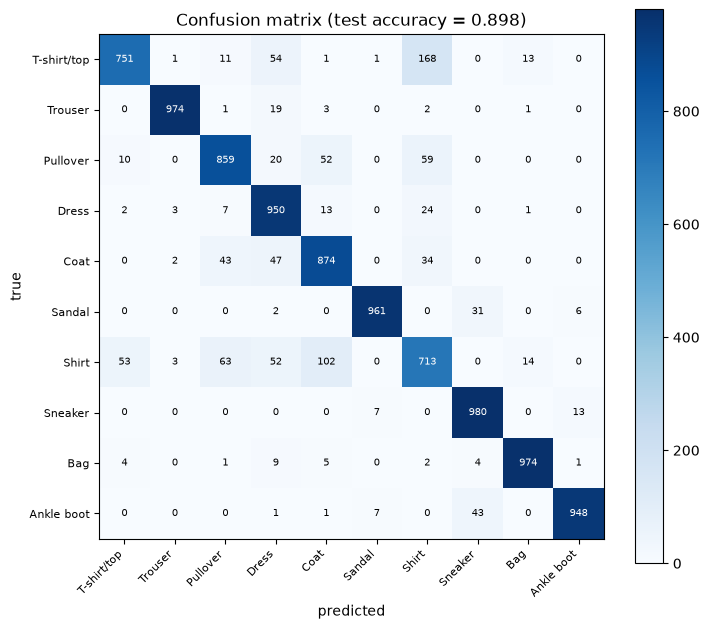

In [27]:
# Draw the confusion matrix. Rows are the true class, columns the prediction.
matrix = confusion_matrix(y_true.numpy(), y_pred.numpy())

figure, ax = plt.subplots(figsize=(7.5, 6.5))
image = ax.imshow(matrix, cmap="Blues")
ax.set_xticks(range(len(w1.CLASSES)))
ax.set_yticks(range(len(w1.CLASSES)))
ax.set_xticklabels(w1.CLASSES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(w1.CLASSES, fontsize=8)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title(f"Confusion matrix (test accuracy = {test_accuracy:.3f})")

# Write the count inside every cell.
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        colour = "white" if matrix[i, j] > matrix.max() / 2 else "black"
        ax.text(j, i, matrix[i, j], ha="center", va="center",
                color=colour, fontsize=7)
figure.colorbar(image)
plt.tight_layout()
plt.show()

In [28]:
# Which pairs of classes does the model confuse most often?
mistakes = []
for i in range(len(w1.CLASSES)):
    for j in range(len(w1.CLASSES)):
        if i != j and matrix[i, j] > 0:
            mistakes.append((matrix[i, j], w1.CLASSES[i], w1.CLASSES[j]))
mistakes.sort(reverse=True)

print("Top 5 confusions (true -> predicted):")
for count, true_name, pred_name in mistakes[:5]:
    print(f"  {count:4d}  {true_name} -> {pred_name}")

Top 5 confusions (true -> predicted):
   168  T-shirt/top -> Shirt
   102  Shirt -> Coat
    63  Shirt -> Pullover
    59  Pullover -> Shirt
    54  T-shirt/top -> Dress


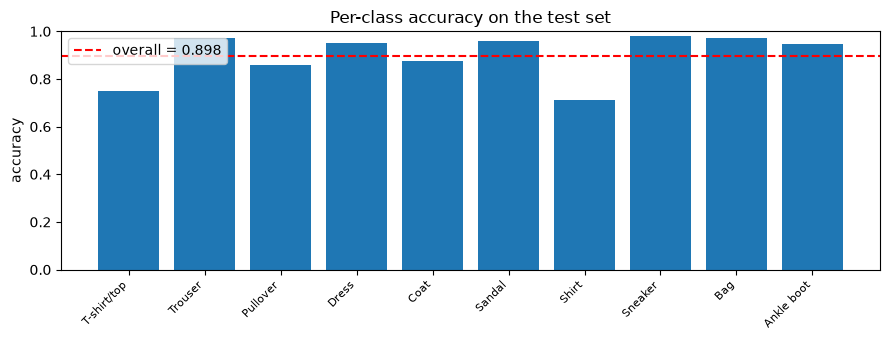

In [29]:
# Per-class accuracy as a bar chart.
per_class_accuracy = matrix.diagonal() / matrix.sum(axis=1)

plt.figure(figsize=(9, 3.5))
plt.bar(range(len(w1.CLASSES)), per_class_accuracy)
plt.axhline(test_accuracy, color="red", linestyle="--",
            label=f"overall = {test_accuracy:.3f}")
plt.xticks(range(len(w1.CLASSES)), w1.CLASSES, rotation=45, ha="right", fontsize=8)
plt.ylabel("accuracy")
plt.ylim(0, 1)
plt.legend()
plt.title("Per-class accuracy on the test set")
plt.tight_layout()
plt.show()

## 8. Looking at single predictions

The model also tells us **how sure** it is. Wrong answers with high confidence
are the most interesting ones to study.

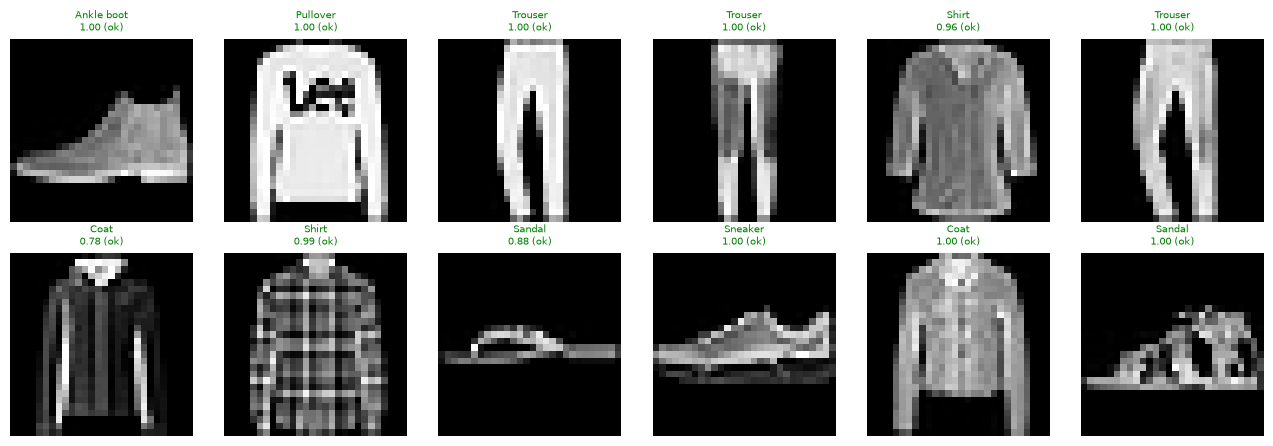

In [30]:
# Show 12 test images with the prediction and the confidence.
test_images, test_labels = next(iter(test_loader))
with torch.no_grad():
    model.eval()
    probabilities = model(test_images.to(DEVICE)).softmax(dim=1).cpu()
predictions = probabilities.argmax(dim=1)

figure, axes = plt.subplots(2, 6, figsize=(13, 4.5))
for ax, image, true_label, pred_label, prob in zip(
        axes.flat, test_images, test_labels, predictions, probabilities):
    picture = image[0] * 0.3530 + 0.2860
    ax.imshow(picture.numpy(), cmap="gray")
    correct = true_label == pred_label
    ax.set_title(f"{w1.CLASSES[pred_label]}\n{prob.max():.2f} "
                 f"({'ok' if correct else 'true: ' + w1.CLASSES[true_label]})",
                 fontsize=7, color="green" if correct else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [31]:
# The most confident mistakes over the whole test set.
wrong = (y_true != y_pred).nonzero(as_tuple=True)[0]
confidence = y_prob[wrong].max(dim=1).values
worst = wrong[confidence.argsort(descending=True)[:8]]

print("Most confident mistakes:")
for index in worst.tolist():
    image, true_label = test_set[index]
    print(f"  true={w1.CLASSES[true_label]:<12} "
          f"predicted={w1.CLASSES[y_pred[index]]:<12} "
          f"confidence={y_prob[index].max():.3f}")

Most confident mistakes:
  true=Ankle boot   predicted=Sandal       confidence=1.000
  true=T-shirt/top  predicted=Dress        confidence=1.000
  true=Sneaker      predicted=Ankle boot   confidence=1.000
  true=Trouser      predicted=Dress        confidence=1.000
  true=T-shirt/top  predicted=Dress        confidence=1.000
  true=Sandal       predicted=Sneaker      confidence=0.999
  true=Ankle boot   predicted=Sandal       confidence=0.999
  true=Coat         predicted=Dress        confidence=0.999


## 9. Save the trained model

In [32]:
save_path = Path("outputs_week01")
save_path.mkdir(exist_ok=True)
torch.save({"state_dict": model.state_dict(),
            "classes": w1.CLASSES,
            "config": {"stem": STEM, "dropout": DROPOUT, "n_train": len(train_set)},
            "test_accuracy": test_accuracy},
           save_path / "resnet18_fashionmnist.pt")
print(f"saved -> {(save_path / 'resnet18_fashionmnist.pt').resolve()}")

saved -> /home/jovyan/lecture-advanceddeeplearning/outputs_week01/resnet18_fashionmnist.pt


## 10. Summary

| Item | Value |
|---|---|
| Dataset | Fashion-MNIST |
| Model | ResNet-18 trained from scratch (`stem="cifar"`) |
| Training images | see `N_TRAIN` above |
| Best validation accuracy | printed in section 5 |
| Test accuracy | printed in section 6 |

What section 3 showed, in one line each:

1. The hand-written backward pass agrees with `autograd` to floating-point
   precision, and finite differences agree to about 1e-8. Backpropagation is
   something you can check, not something you have to trust.
2. With sigmoid the gradient shrinks by orders of magnitude per layer; with
   ReLU + He it stays roughly flat.
3. Inverted dropout keeps the mean activation unchanged, and `nn.Dropout(p)`
   uses the *drop* probability, not the paper's keep probability.
4. Batch normalisation is four lines of arithmetic, and in this experiment it
   is what keeps the larger learning rate from breaking training.
5. The identity shortcut turns a product of Jacobians into a sum, so the first
   layer of a deep network still receives a usable gradient.

## Try it yourself

1. Set `N_TRAIN = None` to train on all 55,000 images. How much does the test
   accuracy improve, and how much longer does it take?
2. Add data augmentation (`transforms.RandomHorizontalFlip()`) to the training
   transform only. Does the gap between train and validation accuracy get smaller?
3. Build the model with `w1.build_model(pretrained=True)` (ImageNet weights) and
   compare the first-epoch accuracy with training from scratch. Note that the
   CIFAR stem is created fresh, so only the deeper stages are pretrained.
4. Set `STEM = "imagenet"` and rerun section 5. How much accuracy do you lose,
   and does the shape table of 3.5 explain it?
5. Set `DROPOUT = 0.3` and compare the train/validation gap with the run above.
6. Change the optimizer to plain SGD with momentum 0.9. Which one needs more epochs?
7. The two hardest classes are usually "Shirt" and "Coat". Look at the images -
   can *you* tell them apart?